In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import sys, pathlib

# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: C:\Users\f.spreemann\qecsim-work


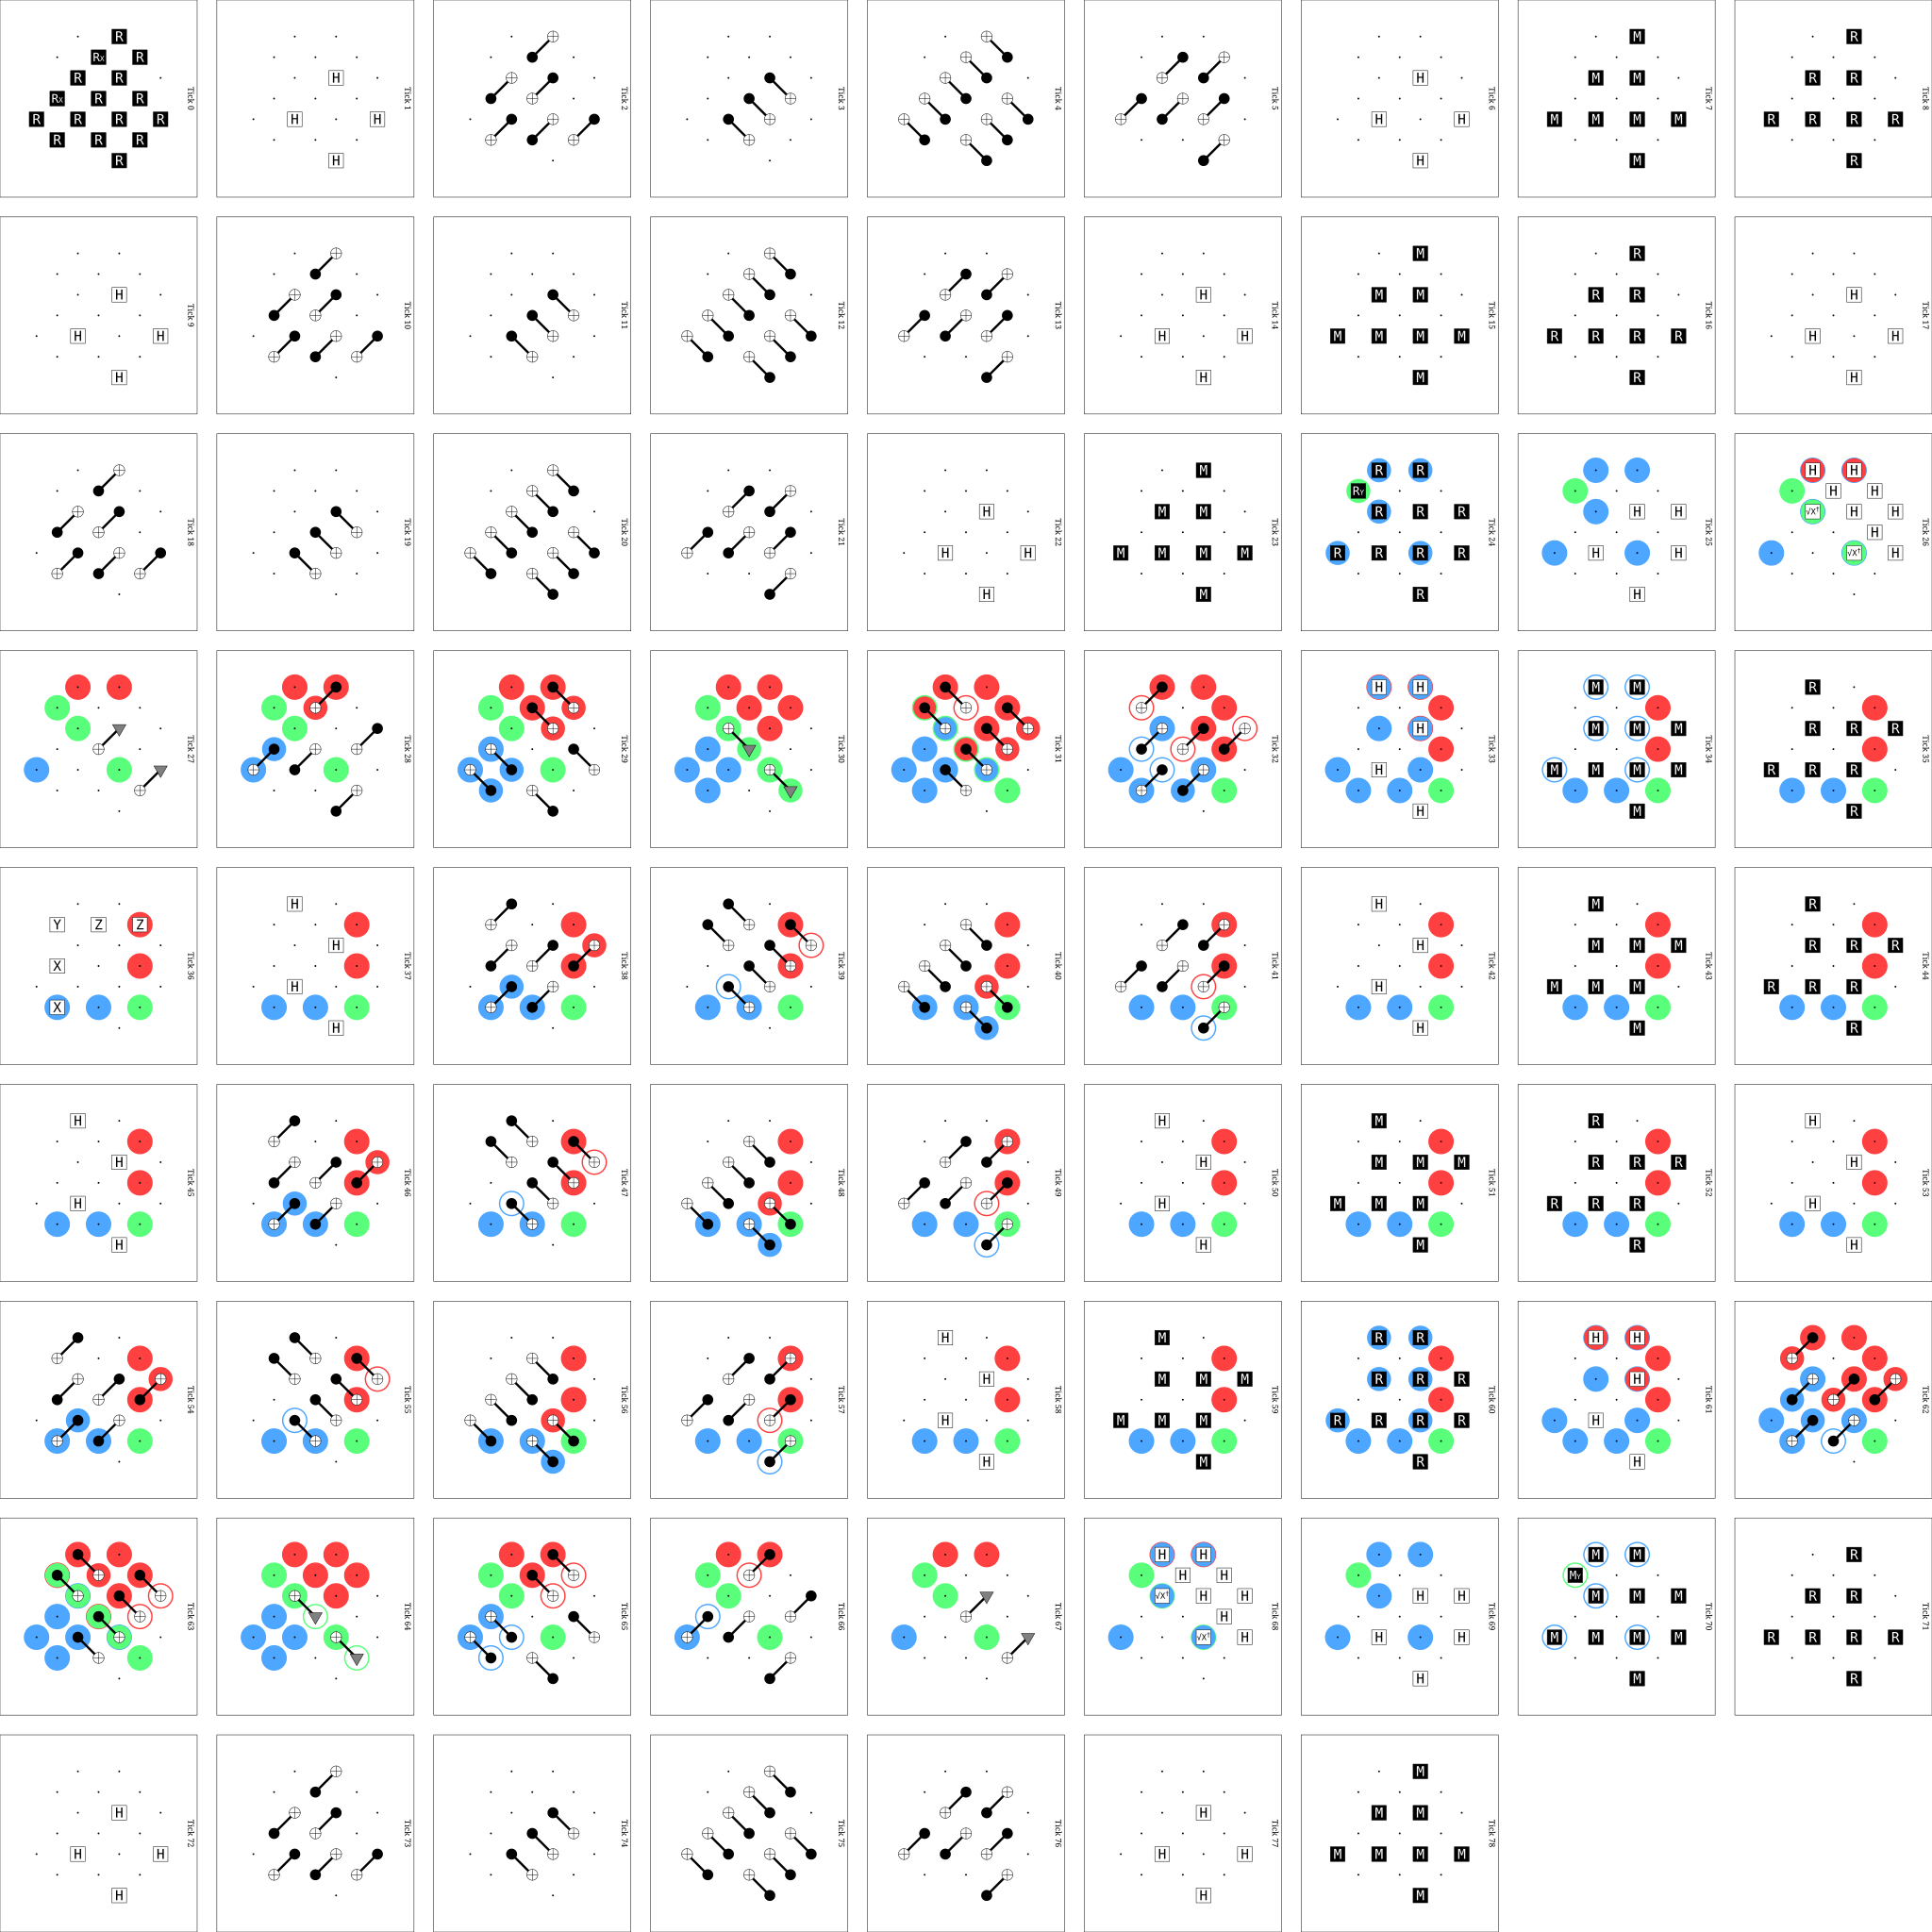

In [35]:
from src.codes.surface_code_rotated.builder import SurfaceBuilder

build = SurfaceBuilder(distance=3, state_init="-i", log_obs="Y")

circuit = build.build_circuit()

circuit.diagram("detslice-with-ops-svg", filter_coords="L0")

In [36]:
from src.codes.lattice_surgery.builder import SurgeryBuilder

In [45]:
test_surgery_builder = SurgeryBuilder(distance=3, control_state_init="Y+", target_state_init="Y+",
                                      control_measure_basis="X", target_measure_basis="Z")

test_surgery_circuit = test_surgery_builder.build_circuit()
test_measurement_rec = test_surgery_builder.get_logical_meas_rec(observable_index=0)

test_surgery_circuit.diagram("detslice-with-ops-svg", filter_coords="L0")

In [41]:
import numpy as np

test_surgery_builder = SurgeryBuilder(distance=3, control_state_init="Z1", target_state_init="Y+",
                                      control_measure_basis="I", target_measure_basis="Y",
                                      )
test_surgery_circuit = test_surgery_builder.build_circuit()
test_measurement_rec = test_surgery_builder.get_logical_meas_rec(observable_index=0)

sampler = test_surgery_circuit.compile_sampler()
results_samples = sampler.sample(shots=1000)

final_res = 0
for i in test_measurement_rec:
    final_res ^= results_samples[:, i].astype(np.int8)
print(final_res)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 